# Employee Attrition Intelligence System

## Notebook 02: Exploratory Data Analysis (EDA)

### Objective

The goal of this notebook is to understand the key drivers of employee attrition by analyzing patterns in the dataset.

We aim to:
- Identify which employee groups are most likely to leave
- Understand how salary, role, age, and tenure affect attrition
- Convert raw data into business insights
- Prepare insights for feature engineering and ML modeling

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

In [4]:
df = pd.read_csv("../data/raw/WA_Fn-UseC_-HR-Employee-Attrition.csv")

print(df.shape)
df.head()

(1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


## Business Context

Attrition is a critical HR problem because replacing employees is costly.

This analysis focuses on:
- Identifying high-risk employee segments
- Understanding behavioral patterns leading to attrition
- Supporting HR decision-making with data

In [5]:
df["Attrition"].value_counts(normalize=True) * 100

Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64

### Insight Focus

We first examine the distribution of attrition to understand class imbalance.

This helps us understand whether attrition is a rare or frequent event.

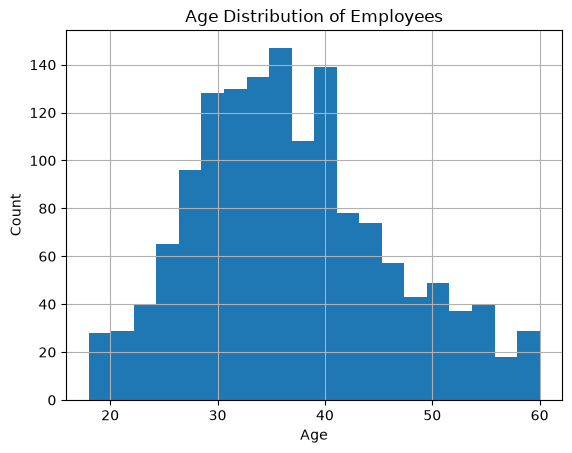

In [6]:
df["Age"].hist(bins=20)
plt.title("Age Distribution of Employees")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

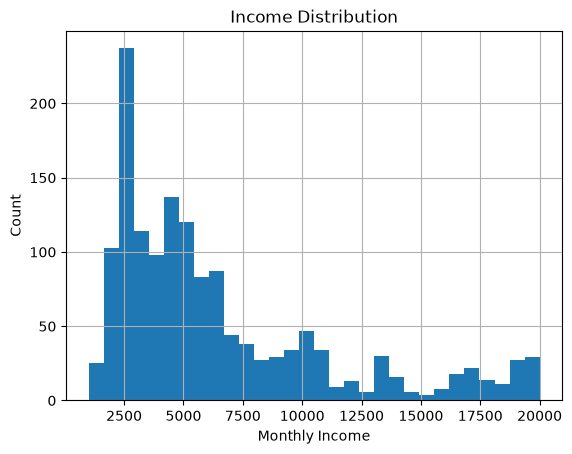

In [7]:
df["MonthlyIncome"].hist(bins=30)
plt.title("Income Distribution")
plt.xlabel("Monthly Income")
plt.ylabel("Count")
plt.show()

### Insight Focus

We analyze distributions to understand workforce structure:
- Age concentration
- Salary distribution patterns

In [8]:
df.groupby("Department")["Attrition"].value_counts(normalize=True).unstack() * 100

Attrition,No,Yes
Department,,
Human Resources,80.952381,19.047619
Research & Development,86.160250,13.839750
Sales,79.372197,20.627803


In [9]:
df.groupby("JobRole")["Attrition"].value_counts(normalize=True).unstack() * 100

Attrition,No,Yes
JobRole,,
Healthcare Representative,93.129771,6.870229
Human Resources,76.923077,23.076923
Laboratory Technician,76.061776,23.938224
Manager,95.098039,4.901961
Manufacturing Director,93.103448,6.896552
Research Director,97.500000,2.500000
Research Scientist,83.904110,16.095890
Sales Executive,82.515337,17.484663
Sales Representative,60.240964,39.759036


In [10]:
df.groupby("Gender")["Attrition"].value_counts(normalize=True).unstack() * 100

Attrition,No,Yes
Gender,,
Female,85.204082,14.795918
Male,82.993197,17.006803


### Key Business Insight Area

We now examine attrition across organizational segments:
- Department
- Job Role
- Gender

This helps identify structural risk areas in the company.

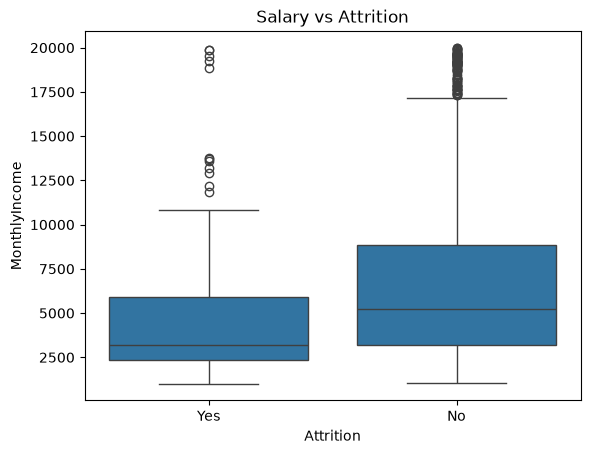

In [11]:
sns.boxplot(x="Attrition", y="MonthlyIncome", data=df)
plt.title("Salary vs Attrition")
plt.show()

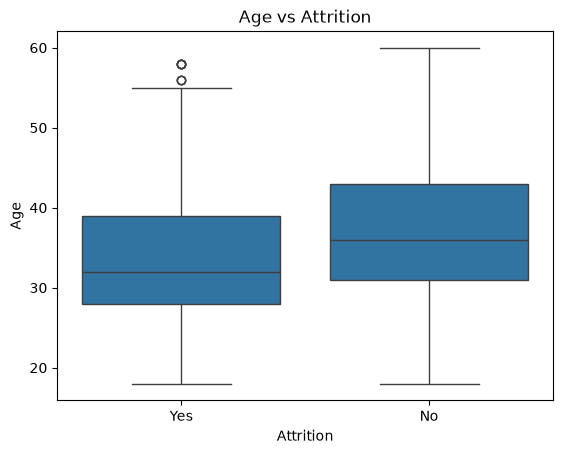

In [12]:
sns.boxplot(x="Attrition", y="Age", data=df)
plt.title("Age vs Attrition")
plt.show()

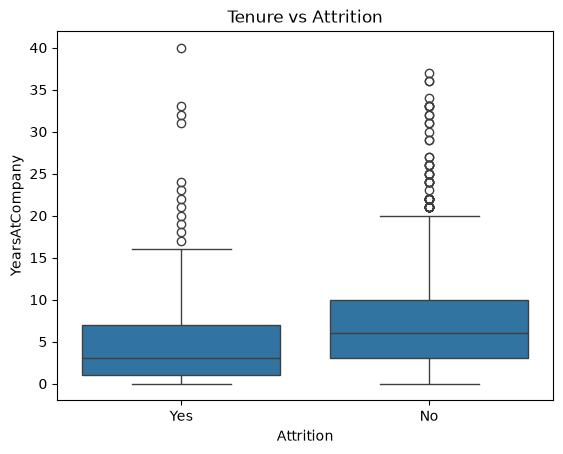

In [13]:
sns.boxplot(x="Attrition", y="YearsAtCompany", data=df)
plt.title("Tenure vs Attrition")
plt.show()

### Key Insight Focus

We now analyze what differentiates employees who leave vs stay:
- Compensation
- Experience
- Tenure

These are expected to be the strongest predictors of attrition.

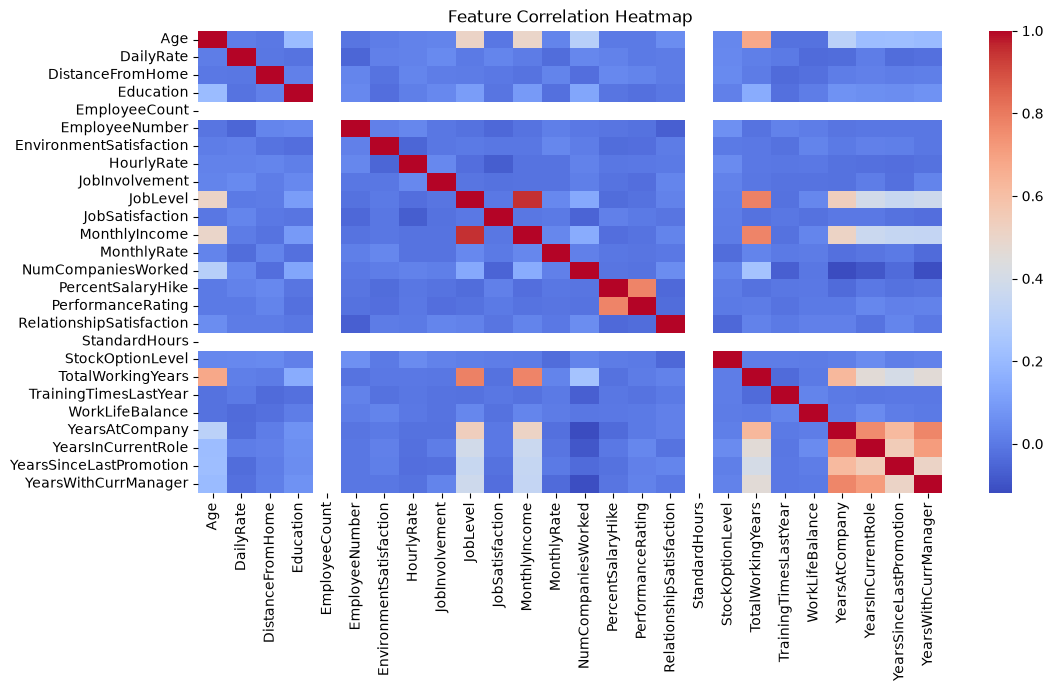

In [14]:
plt.figure(figsize=(12,6))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

## Key Findings (Preliminary Insights)

Based on EDA:

- Attrition varies across job roles and departments
- Salary appears to influence retention
- Younger employees may show higher attrition tendency
- Lower tenure employees may be more likely to leave

These insights will guide feature engineering and predictive modeling.

## Next Step: Feature Engineering

Based on EDA findings, we will create new features such as:
- Salary bands
- Tenure groups
- Risk indicators
- Satisfaction aggregates

These features will improve model interpretability and performance.

## Insight 1: Overall Attrition Rate

Understanding the proportion of employees who leave vs stay is critical to establish baseline attrition risk in the organization.

In [15]:
attrition_rate = df["Attrition"].value_counts(normalize=True) * 100
attrition_rate

Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64

## Insight 2: Attrition by Department

This analysis helps identify whether certain departments have higher attrition rates, indicating structural or managerial issues.

In [16]:
df.groupby("Department")["Attrition"].value_counts(normalize=True).unstack() * 100

Attrition,No,Yes
Department,,
Human Resources,80.952381,19.047619
Research & Development,86.160250,13.839750
Sales,79.372197,20.627803


### Key Insight

- Sales department shows the highest attrition rate (~20.6%), indicating potential retention challenges.
- Human Resources also shows elevated attrition (~19%), which is notable given its expected stability.
- Research & Development has the lowest attrition (~13.8%), suggesting stronger employee retention.

These differences indicate that attrition is not uniform across the organization and may be influenced by department-specific factors such as workload, role expectations, or management structure.

## Insight 3: Attrition by Job Role

This analysis breaks down attrition at a more granular level than department.

It helps identify specific job roles that may have retention risks, enabling targeted HR interventions rather than broad departmental policies.

In [17]:
df.groupby("JobRole")["Attrition"].value_counts(normalize=True).unstack() * 100

Attrition,No,Yes
JobRole,,
Healthcare Representative,93.129771,6.870229
Human Resources,76.923077,23.076923
Laboratory Technician,76.061776,23.938224
Manager,95.098039,4.901961
Manufacturing Director,93.103448,6.896552
Research Director,97.500000,2.500000
Research Scientist,83.904110,16.095890
Sales Executive,82.515337,17.484663
Sales Representative,60.240964,39.759036


### Key Insight

- Sales Representative has the highest attrition rate (~39.8%), indicating a high-risk entry-level sales role.
- Laboratory Technician and Human Resources also show elevated attrition (~23%), suggesting structural or role-related dissatisfaction.
- Senior roles such as Manager and Research Director show very low attrition (<5%), indicating strong retention at higher job levels.

### Business Interpretation

Attrition is heavily concentrated in entry-level and operational roles, suggesting that early-career employee experience and role design are key retention drivers.

## Insight 4: Monthly Income vs Attrition

This analysis explores whether compensation levels influence employee attrition.

Salary is typically one of the strongest predictors of retention and is expected to show clear separation between employees who stay and those who leave.

In [18]:
df.groupby("Attrition")["MonthlyIncome"].describe()

,count,mean,std,min,25%,50%,75%,max
Attrition,,,,,,,,
No,1233.0,6832.739659,4818.208001,1051.0,3211.0,5204.0,8834.0,19999.0
Yes,237.0,4787.092827,3640.210367,1009.0,2373.0,3202.0,5916.0,19859.0


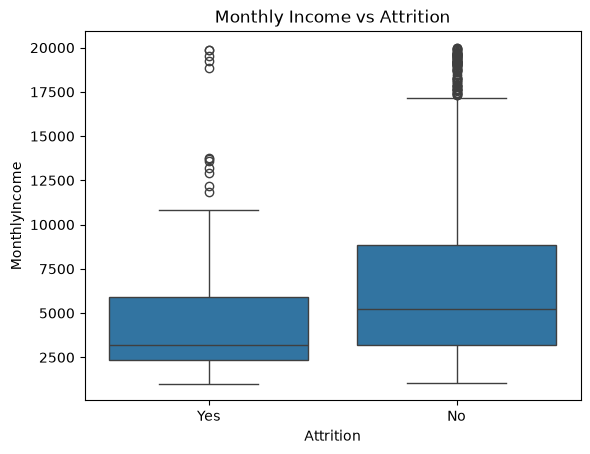

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.boxplot(x="Attrition", y="MonthlyIncome", data=df)
plt.title("Monthly Income vs Attrition")
plt.show()

### Key Insight

Employees who left the company have significantly lower monthly income compared to those who stayed.

- Median income for employees who left is substantially lower (~3202 vs ~5204)
- Lower salary bands show higher concentration of attrition
- However, overlap in high-income ranges indicates salary alone is not a sufficient predictor

### Business Interpretation

Compensation is a strong but not exclusive driver of attrition. It should be analyzed alongside role, tenure, and satisfaction to fully understand employee exit behavior.

## Insight 5: Age vs Attrition

This analysis explores how employee age relates to attrition behavior.

Age is a proxy for career stage and may indicate different retention patterns across early-career, mid-career, and senior employees.

In [20]:
df.groupby("Attrition")["Age"].describe()

,count,mean,std,min,25%,50%,75%,max
Attrition,,,,,,,,
No,1233.0,37.561233,8.88836,18.0,31.0,36.0,43.0,60.0
Yes,237.0,33.607595,9.68935,18.0,28.0,32.0,39.0,58.0


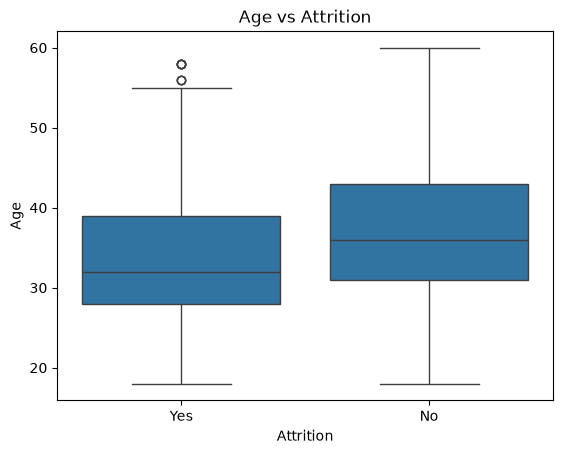

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.boxplot(x="Attrition", y="Age", data=df)
plt.title("Age vs Attrition")
plt.show()

### Key Insight

Employees who left the company are, on average, younger than those who stayed (33.6 vs 37.6 years).

This indicates higher attrition risk in early career stages, potentially due to factors such as career exploration, role expectations, or growth opportunities.

However, attrition is present across all age groups, suggesting that age alone is not a sufficient predictor.

### Business Interpretation

Retention strategies should focus on early-career employees through improved onboarding, career progression visibility, and engagement programs.

## Insight 6: Tenure (Years at Company) vs Attrition

This analysis examines how employee tenure relates to attrition behavior.

Tenure is a key indicator of employee retention patterns and helps identify when employees are most likely to leave the organization.

In [22]:
df.groupby("Attrition")["YearsAtCompany"].describe()

,count,mean,std,min,25%,50%,75%,max
Attrition,,,,,,,,
No,1233.0,7.369019,6.096298,0.0,3.0,6.0,10.0,37.0
Yes,237.0,5.130802,5.949984,0.0,1.0,3.0,7.0,40.0


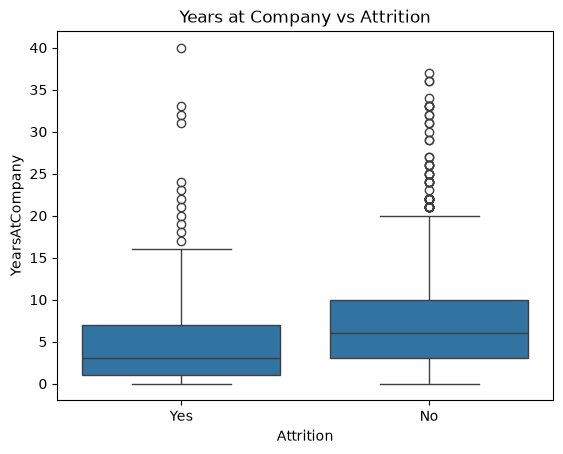

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.boxplot(x="Attrition", y="YearsAtCompany", data=df)
plt.title("Years at Company vs Attrition")
plt.show()

### Key Insight

Employees who left the company show significantly lower tenure compared to those who stayed.

Attrition is heavily concentrated in the early years of employment, indicating a strong early churn pattern.

### Business Interpretation

The organization appears to face challenges in retaining employees during the initial stages of employment. Improving onboarding, role clarity, and early career engagement may significantly reduce attrition.

## Insight 7: Job Satisfaction & Environment Satisfaction vs Attrition

This analysis explores behavioral and workplace experience factors affecting employee attrition.

Unlike demographic or compensation variables, satisfaction metrics reflect employee sentiment and work environment quality, making them important but potentially noisy predictors.


In [24]:
df.groupby("Attrition")["JobSatisfaction"].describe()

,count,mean,std,min,25%,50%,75%,max
Attrition,,,,,,,,
No,1233.0,2.778589,1.093277,1.0,2.0,3.0,4.0,4.0
Yes,237.0,2.468354,1.118058,1.0,1.0,3.0,3.0,4.0


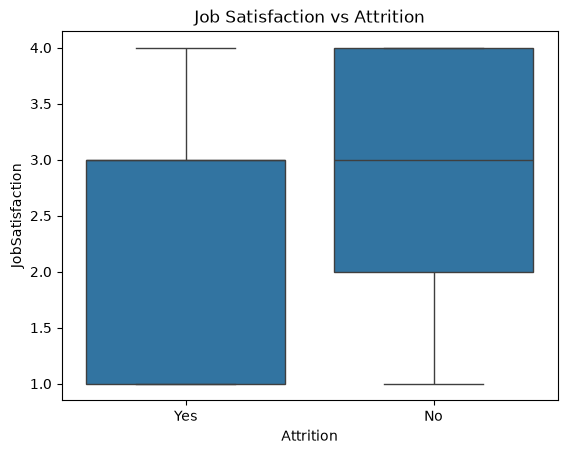

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.boxplot(x="Attrition", y="JobSatisfaction", data=df)
plt.title("Job Satisfaction vs Attrition")
plt.show()

In [25]:
df.groupby("Attrition")["EnvironmentSatisfaction"].describe()

,count,mean,std,min,25%,50%,75%,max
Attrition,,,,,,,,
No,1233.0,2.771290,1.071132,1.0,2.0,3.0,4.0,4.0
Yes,237.0,2.464135,1.169791,1.0,1.0,3.0,4.0,4.0


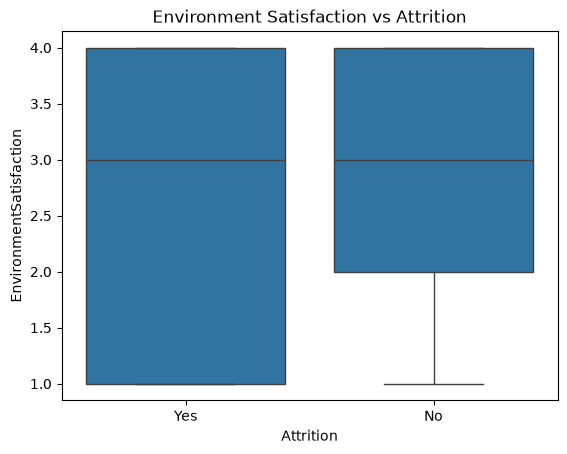

In [27]:
sns.boxplot(x="Attrition", y="EnvironmentSatisfaction", data=df)
plt.title("Environment Satisfaction vs Attrition")
plt.show()

### Key Insight

Employees who left the company show slightly lower Job Satisfaction and Environment Satisfaction compared to those who stayed.

However, the distribution overlaps significantly, indicating that satisfaction alone is not a strong standalone predictor of attrition.

### Business Interpretation

Employee sentiment contributes to attrition risk but should be analyzed in combination with structural factors such as compensation, tenure, and job role for meaningful insights.